# Potato Disease Project

## Data Exploration

In [2]:
from glob import glob

file_paths = {
    "Healthy" : glob("./data/PlantVillage/Potato___healthy/*"),
    "Early-Blight" : glob("./data/PlantVillage/Potato___Early_blight/*"),
    "Late-Blight" : glob("./data/PlantVillage/Potato___Late_blight/*")
}


In [3]:
FILES_PATH = file_paths["Healthy"]
# Checking if all file have the same format
for file_path in FILES_PATH:
    file_extension = (file_path.split("."))[-1]

    if file_extension.lower() != "jpg":
        print(file_extension)

In [4]:
print(f"Number of Healthy Potatoes: {len(file_paths["Healthy"])}")
print(f"Number of Potatoes with Early Blight: {len(file_paths["Early-Blight"])}")
print(f"Number of Potatoes with Late Blight: {len(file_paths["Late-Blight"])}")

Number of Healthy Potatoes: 152
Number of Potatoes with Early Blight: 1000
Number of Potatoes with Late Blight: 1000


As we can see, there is clear class imbalance. We must also try checking the diversity of the data.

Let us start by viewing some of the images.

In [5]:
from IPython.display import HTML, display
import random

# Replace with your actual file paths
IMAGE_PATHS = list()

for paths in file_paths.values():
    IMAGE_PATHS += paths

random.shuffle(IMAGE_PATHS)
NUMBER_OF_IMAGES = 45

# Build HTML string with images side-by-side
html_content = "".join(
    f'<div style="display:inline-block; margin:10px;">'
    f'<img src="{path}" width="200"/>'
    f'</div>'
    for path in IMAGE_PATHS[:NUMBER_OF_IMAGES]
)

display(HTML(html_content))


I can see that most of the leaves are held upright. Maybe it will be good to apply some image augmentation using rotation...

In [26]:
from typing import List
import cv2
import matplotlib.pyplot as plt
import random

max_file_count = 0

# Get maximum number of files
for values in file_paths.values():
    if len(values) > max_file_count:
        max_file_count = len(values)

num_loops = max_file_count // len(file_paths["Healthy"])
healthy_image_data = [cv2.imread(img_path) for img_path in file_paths["Healthy"]]

augmented_healthy_image_data = list()
augmented_healthy_image_data.extend(healthy_image_data)

def augment_data(files):
    for _ in range(num_loops):
        for img in healthy_image_data:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            center = (img_rgb.shape[1] // 2, img_rgb.shape[0] // 2)
            angle = random.randint(-359,360)
            scale = random.randint(7,14) / 10.0

            rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
            rotated_image = cv2.warpAffine(img_rgb, rotation_matrix, (img.shape[1], img.shape[0]))

            augmented_healthy_image_data.append(rotated_image)

augment_data(healthy_image_data)


In [27]:
len(augmented_healthy_image_data)

1064

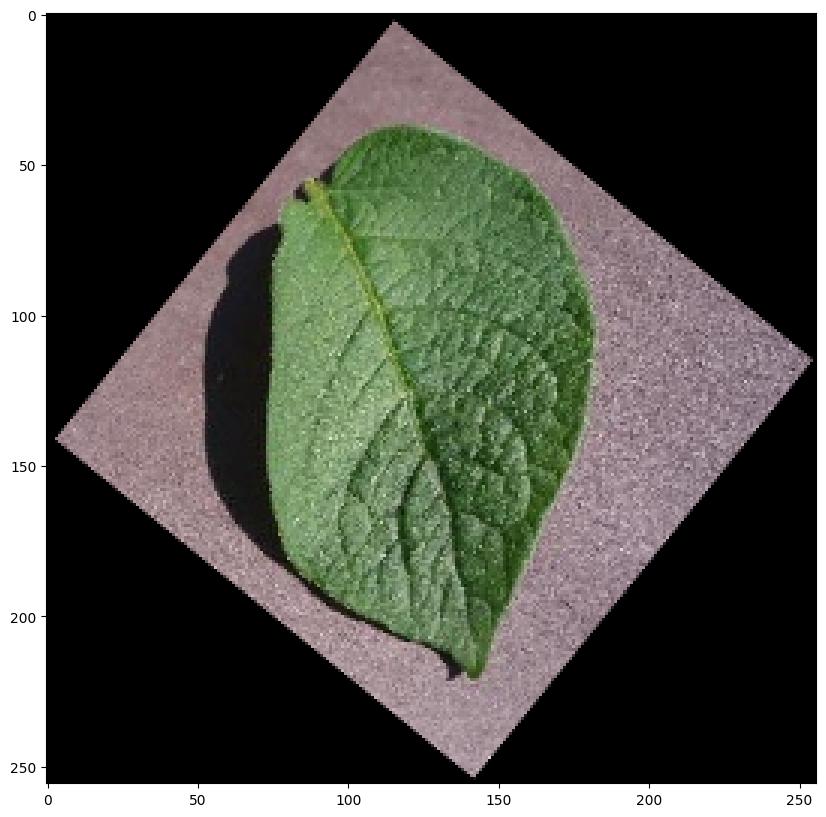

In [30]:
fig, axs = plt.subplots(1,1,figsize=(10,10))
axs.imshow(augmented_healthy_image_data[-2])

plt.show()